# Feature Engineering Summary

1. Data cleaning: : 'TotalCharges' 

In [3]:
1. 

1.0

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sns.set_theme(style="whitegrid")
# pd.set_option('display.max_columns', None)

In [5]:
# Load the dataset
df = pd.read_csv('kaggle_raw_data.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [6]:
# Handling missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

#dropping irrelevant columns
df.drop(['customerID'], axis=1, inplace=True)
df.shape


(7043, 20)

In [7]:
# Feature Engineering

# 1. Avg Charge : average charge per month to detect recent price hikes or discounts
df['avg_monthly_charge'] = df['TotalCharges'] / (df['tenure'] + 1)


# 2. Charge ratio : relative charge ratio of total charges to monthly charges to detect recent price hikes or discounts
df['charge_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

# 3. Tenure group : categorizing tenure into groups to detect patterns in churn based on customer tenure

df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 60, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-5yr', '5-6yr']
)

#4. Service Score : How many add-on services each customer uses?
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df['service_score'] = df[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)


print("New features added. Shape:", df.shape)
print("\nTenure Group distribution:\n", df['tenure_group'].value_counts())
print("\nService Score distribution:\n", df['service_score'].value_counts().sort_index())


New features added. Shape: (7043, 24)

Tenure Group distribution:
 tenure_group
0-1yr    2175
2-4yr    1594
5-6yr    1407
1-2yr    1024
4-5yr     832
Name: count, dtype: int64

Service Score distribution:
 service_score
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64


/var/folders/rh/x8rtcsmd4hd9n6yft69qcc680000gn/T/ipykernel_21223/3542142192.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='avg_monthly_charge', ax=axes[0], palette='Set2')
/var/folders/rh/x8rtcsmd4hd9n6yft69qcc680000gn/T/ipykernel_21223/3542142192.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='charge_ratio', ax=axes[1], palette='Set2')


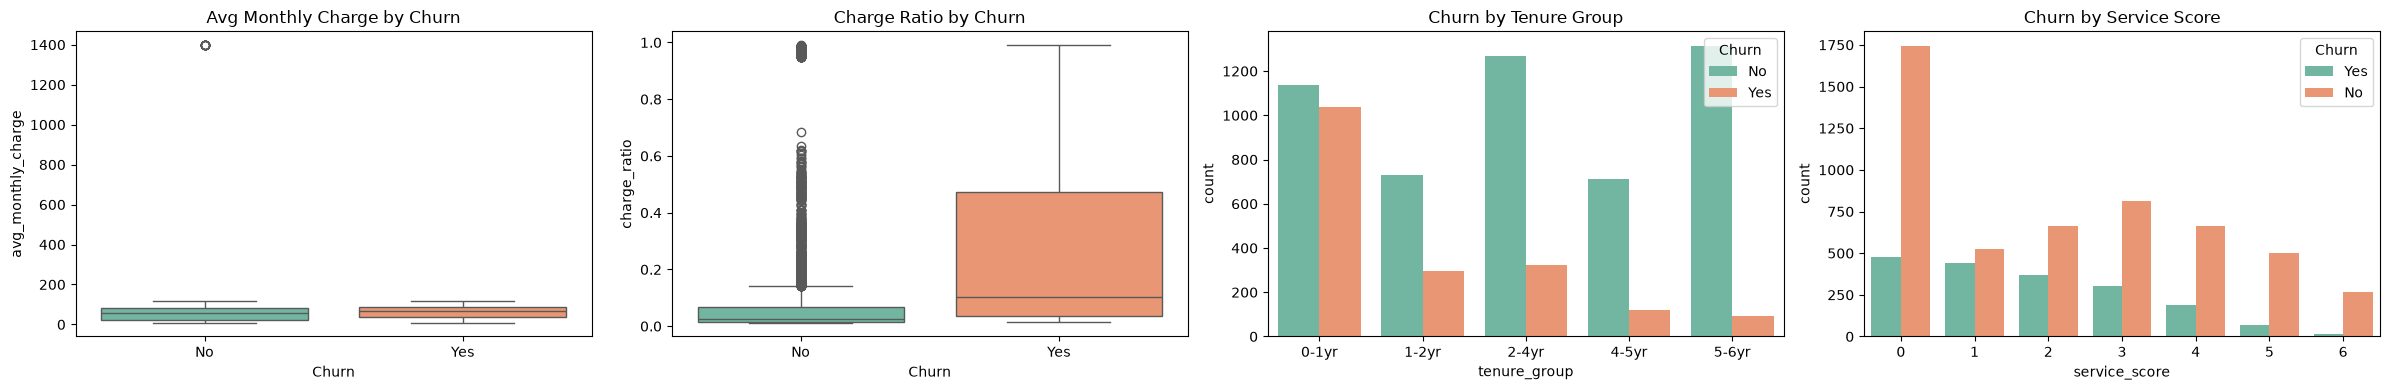

In [8]:
#Visulaizing new features
fig, axes = plt.subplots(1, 4, figsize=(24, 4))

# avg monthly charge vs churn
sns.boxplot(data=df, x='Churn', y='avg_monthly_charge', ax=axes[0], palette='Set2')
axes[0].set_title('Avg Monthly Charge by Churn')

# Charge ratio vs churn
sns.boxplot(data=df, x='Churn', y='charge_ratio', ax=axes[1], palette='Set2')
axes[1].set_title('Charge Ratio by Churn')

# Tenure group vs churn
sns.countplot(data=df, x='tenure_group', hue='Churn', ax=axes[2], palette='Set2')
axes[2].set_title('Churn by Tenure Group')

# Service score vs churn
sns.countplot(data=df, x='service_score', hue='Churn', ax=axes[3], palette='Set2')
axes[3].set_title('Churn by Service Score')

plt.tight_layout()
plt.savefig('new_features.png', dpi=150)
plt.show()

In [9]:
#Encoding categorical variables: Binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
    'PaperlessBilling', 'Churn']

binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}

for col in binary_cols:
    df[col] = df[col].map(binary_map)


print(df[binary_cols].head())

   gender  Partner  Dependents  PhoneService  PaperlessBilling  Churn
0       0        1           0             0                 1      0
1       1        0           0             1                 0      0
2       1        0           0             1                 1      1
3       1        0           0             0                 0      0
4       0        0           0             1                 1      1


In [10]:
# One hot encoding for multi-class categorical variables
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract',
    'PaymentMethod', 'tenure_group'
]

existing_multi_cat_cols = [
    col for col in multi_cat_cols if col in df.columns
]
df = pd.get_dummies(df, columns=existing_multi_cat_cols, drop_first=False)

print("Encoded columns:", existing_multi_cat_cols)
print("Columns:", df.columns.tolist())

Encoded columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'tenure_group']
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'avg_monthly_charge', 'charge_ratio', 'service_score', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet ser

In [11]:
#Final dataset shape
print("Final dataset shape:", df.shape)

#Nulls, value counts, and data types
print("\nNull values:\n", df.isnull().sum()) 
print("\nData types:\n", df.dtypes)
print("\nValue counts for Churn:\n", df['Churn'].value_counts())    

Final dataset shape: (7043, 49)

Null values:
 gender                                     0
SeniorCitizen                              0
Partner                                    0
Dependents                                 0
tenure                                     0
PhoneService                               0
PaperlessBilling                           0
MonthlyCharges                             0
TotalCharges                               0
Churn                                      0
avg_monthly_charge                         0
charge_ratio                               0
service_score                              0
MultipleLines_No                           0
MultipleLines_No phone service             0
MultipleLines_Yes                          0
InternetService_DSL                        0
InternetService_Fiber optic                0
InternetService_No                         0
OnlineSecurity_No                          0
OnlineSecurity_No internet service         0
OnlineSe

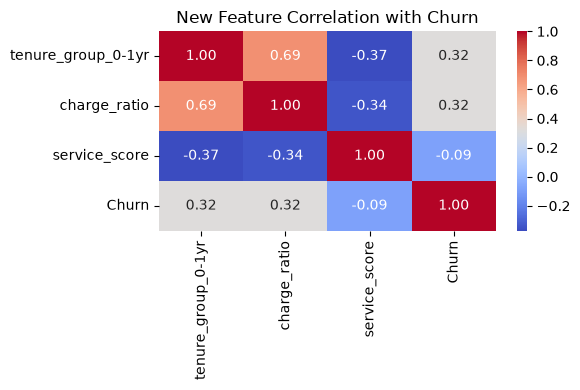

In [12]:
# Correlation heatmap with the new features 
new_feature_corr = df[['tenure_group_0-1yr', 'charge_ratio',
                         'service_score', 'Churn']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(new_feature_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('New Feature Correlation with Churn')
plt.tight_layout()
plt.savefig('new_feature_correlation.png', dpi=150)
plt.show()

In [13]:
df.to_csv('Edited_Data.csv', index=False)
print("Final shape:", df.shape)

Final shape: (7043, 49)
